<a href="https://colab.research.google.com/github/genaiconference/When-Agents-Meet-Living-Graphs/blob/main/CineCraft_AI_Director_Clone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Living Graph Memory - Director's Digital AI Twin

### Graphiti demonstrated as an *evolving creative identity*, not a memory database

> **RAG remembers the director's notes.**
> **Graphiti remembers the director's mind changing.**
> **CineCraft AI, powered by Graphiti becomes the director's evolving digital twin.**

---

This notebook maps Graphiti's core mechanics to a memorable **seven-day “director clone” storyline**. Each cell demonstrates a distinct capability with a visible *before/after* effect.

The strongest demo is not *“the graph remembers seven notes.”* It is *“the clone can distinguish **what** the director believed, **when** it was true, **when** the system learned it, and **why** the decision changed.”*

## The seven-stage sequence

**PITCH → PRESSURE → PIVOT → PAST → PROOF → PATTERN → PERSONA**

| Stage | Meaning |
|-------|---------|
| **PITCH** | What the director initially imagined |
| **PRESSURE** | Real-world constraints arrive |
| **PIVOT** | The director changes the vision |
| **PAST** | An older idea is discovered later |
| **PROOF** | Every decision can be traced to its source |
| **PATTERN** | The graph discovers the director's recurring creative DNA |
| **PERSONA** | The AI clone speaks and decides like the director |

## The two clocks your audience must understand

Every important creative fact can have **two timelines**:

1. **Director time** — *When was the idea actually true?* → `valid_at`, `invalid_at`
2. **Memory time** — *When did CineCraft AI learn the idea?* → `created_at`, `expired_at`

> Arun decided on **Tuesday** that Aham represents Maya's father. But CineCraft AI only received the voice note on **Thursday**.
>
> Therefore: `valid_at = Tuesday`, `created_at = Thursday`.

This is the killer **bi-temporal** demonstration.

## Setup: Install & Configure

Graphiti needs a Neo4j (or FalkorDB) backend and an LLM/embedder (OpenAI or Azure OpenAI). Set the environment variables below before running.

In [1]:
# Install dependencies (uncomment on first run)
%pip install graphiti_core==0.29.3 python-dotenv nest_asyncio --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 361.5/361.5 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.4/468.4 kB 21.2 MB/s eta 0:00:00


In [2]:
import os
from datetime import datetime, timezone, timedelta
from dotenv import load_dotenv
import nest_asyncio

# Allow await in notebook cells
nest_asyncio.apply()
load_dotenv()

# ---- Backend / model configuration ----
NEO4J_URI = os.environ.get("NEO4J_URI")
NEO4J_USER = os.environ.get("NEO4J_USERNAME")
NEO4J_PASSWORD = os.environ.get("NEO4J_PASSWORD")

# OpenAI (or Azure OpenAI) keys are read from the environment by Graphiti
assert os.environ.get("OPENAI_API_KEY"), "Set OPENAI_API_KEY (or configure Azure clients below)"

print("Config loaded. Neo4j:", NEO4J_URI)

Config loaded. Neo4j: bolt://100.53.52.254


In [3]:
# A small helper so the whole week uses one consistent Monday-9am anchor.
# We build all the 'director-time' reference timestamps relative to this.
WEEK_MONDAY_9AM = datetime(2026, 6, 1, 9, 0, tzinfo=timezone.utc)  # a real Monday

def day(name, hour=9, minute=0):
    """Return a reference_time for a given weekday of the demo week."""
    offsets = {"MON": 0, "TUE": 1, "WED": 2, "THU": 3, "FRI": 4, "SAT": 5, "SUN": 6}
    base = WEEK_MONDAY_9AM.replace(hour=hour, minute=minute)
    return base + timedelta(days=offsets[name.upper()])

for d in ["MON", "TUE", "WED", "THU", "FRI", "SAT", "SUN"]:
    print(d, "->", day(d))

MON -> 2026-06-01 09:00:00+00:00
TUE -> 2026-06-02 09:00:00+00:00
WED -> 2026-06-03 09:00:00+00:00
THU -> 2026-06-04 09:00:00+00:00
FRI -> 2026-06-05 09:00:00+00:00
SAT -> 2026-06-06 09:00:00+00:00
SUN -> 2026-06-07 09:00:00+00:00


## Cell 0 — Create the Director Clone

We define a **namespace** (`group_id`) so this director's mind lives in an isolated graph, a **saga id** for week-level summarisation, and a **custom ontology** of film-domain entities and relationships.

> Graphiti supports prescribed custom entity and edge types through Pydantic models. It can also let structure *emerge* when you do not prescribe everything upfront.

In [4]:
import asyncio
from graphiti_core import Graphiti
# from graphiti_core.llm_client.config import LLMConfig

# Using the specific gpt-5.5 identifier as requested for project access
# llm_config = LLMConfig(model="gpt-5.5")

In [5]:
GROUP_ID = "director_arun_project_aham"
SAGA_ID = "aham_creative_evolution_week_1"

from graphiti_core.llm_client import OpenAIClient

# Re-initializing the client with gpt-5.5
# llm_client_instance = OpenAIClient(config=llm_config)

graphiti = Graphiti(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD)

await graphiti.build_indices_and_constraints()
print(f"Director clone namespace ready :", GROUP_ID)

Director clone namespace ready : director_arun_project_aham


In [6]:
from pydantic import BaseModel, Field

# ---------------- Custom ENTITY types ----------------
class Director(BaseModel):
    """A film director who makes creative decisions."""
    creative_signature: str | None = Field(None, description="Recurring creative tendencies")

class FilmProject(BaseModel):
    """A movie being developed."""
    logline: str | None = Field(None, description="One-line description of the film")

class Character(BaseModel):
    """A character in the film."""
    role: str | None = Field(None, description="Protagonist, antagonist, etc.")

class Scene(BaseModel):
    """A scene or sequence in the film."""

class Location(BaseModel):
    """A physical or fictional shooting location."""

class Theme(BaseModel):
    """A thematic idea explored by the film."""

class CreativeConstraint(BaseModel):
    """A production limit such as budget or schedule."""

class ReferenceFilm(BaseModel):
    """An inspirational reference film."""

class CrewMember(BaseModel):
    """A crew member such as producer or cinematographer."""

class AudienceFeedback(BaseModel):
    """Feedback from a screening panel or audience."""

class CreativeDecision(BaseModel):
    """A concrete creative decision made by the director."""

class VisualMotif(BaseModel):
    """A recurring visual or sensory motif."""

entity_types = {
    "Director": Director,
    "FilmProject": FilmProject,
    "Character": Character,
    "Scene": Scene,
    "Location": Location,
    "Theme": Theme,
    "CreativeConstraint": CreativeConstraint,
    "ReferenceFilm": ReferenceFilm,
    "CrewMember": CrewMember,
    "AudienceFeedback": AudienceFeedback,
    "CreativeDecision": CreativeDecision,
    "VisualMotif": VisualMotif,
}

# ---------------- Custom EDGE (relationship) types ----------------
class DIRECTS(BaseModel):
    """A director directs a film project."""

class PREFERS_GENRE(BaseModel):
    """A project prefers/uses a genre."""

class SET_IN(BaseModel):
    """A project is set in a location/time."""

class HAS_PROTAGONIST(BaseModel):
    """A project has a protagonist."""

class HAS_ENDING(BaseModel):
    """A project has a particular ending."""

class INSPIRED_BY(BaseModel):
    """A project is inspired by a reference."""

class REJECTS(BaseModel):
    """A person rejects an idea."""

class APPROVES(BaseModel):
    """A person approves an idea."""

class CONSTRAINED_BY(BaseModel):
    """A project is constrained by a production limit."""

class REPLACES(BaseModel):
    """A new fact replaces an older one."""

class REQUESTS(BaseModel):
    """A stakeholder requests something."""

class RESPONDS_TO(BaseModel):
    """A decision responds to feedback/request."""

class PRESERVES(BaseModel):
    """A character/decision preserves something."""

edge_types = {
    "DIRECTS": DIRECTS, "PREFERS_GENRE": PREFERS_GENRE, "SET_IN": SET_IN,
    "HAS_PROTAGONIST": HAS_PROTAGONIST, "HAS_ENDING": HAS_ENDING,
    "INSPIRED_BY": INSPIRED_BY, "REJECTS": REJECTS, "APPROVES": APPROVES,
    "CONSTRAINED_BY": CONSTRAINED_BY, "REPLACES": REPLACES,
    "REQUESTS": REQUESTS, "RESPONDS_TO": RESPONDS_TO, "PRESERVES": PRESERVES,
}

# Constrain which edges are allowed between which entity pairs.
# This is important: it stops Graphiti from treating an unrelated edge (e.g. DIRECTS)
# as a "replacement candidate" for a contradicting one (e.g. SET_IN), which was causing
# 'Director Arun directs Project AHAM' to be wrongly invalidated on Day 2.
# A permissive fallback (("*","*")) still lets novel/emergent relations appear.
edge_type_map = {
    ("Director", "FilmProject"): ["DIRECTS", "REJECTS", "APPROVES", "REQUESTS"],
    ("FilmProject", "Theme"): ["PREFERS_GENRE"],
    ("FilmProject", "Location"): ["SET_IN"],
    ("FilmProject", "Character"): ["HAS_PROTAGONIST"],
    ("FilmProject", "Scene"): ["HAS_ENDING"],
    ("FilmProject", "ReferenceFilm"): ["INSPIRED_BY"],
    ("FilmProject", "CreativeConstraint"): ["CONSTRAINED_BY"],
    ("CrewMember", "FilmProject"): ["REQUESTS", "REJECTS", "APPROVES"],
    ("Director", "CreativeDecision"): ["APPROVES", "REJECTS", "REQUESTS"],
    ("CreativeDecision", "AudienceFeedback"): ["RESPONDS_TO"],
    ("Character", "Character"): ["PRESERVES"],
    ("CreativeDecision", "CreativeDecision"): ["REPLACES"],
    # Permissive fallback so unexpected creative relations can still emerge.
    ("*", "*"): list(edge_types.keys()),
}

print(f"Ontology ready: {len(entity_types)} entity types, {len(edge_types)} edge types.")

Ontology ready: 12 entity types, 13 edge types.


In [7]:
from graphiti_core.nodes import EpisodeType
from openai import OpenAI
_llm = OpenAI()

async def add_creative_episode(name, body, reference_time, source=EpisodeType.text,
                               description="", group_id=GROUP_ID):
    result = await graphiti.add_episode(
        name=name,
        episode_body=body,
        source=source,
        source_description=description,
        reference_time=reference_time,
        group_id=group_id,
        entity_types=entity_types,
        edge_types=edge_types,
        edge_type_map=edge_type_map,
    )
    print(f"✓ Ingested '{name}'")
    print(f"   nodes: {[n.name for n in result.nodes]}")
    print(f"   edges: {[e.name for e in result.edges]}")

async def recall_facts(query, center_node_uuid=None, group_id=GROUP_ID,
                       num=10, include_invalid=True):
    results = await graphiti.search(query=query, group_ids=[group_id], center_node_uuid=center_node_uuid, num_results=num)
    facts = []
    for r in results:
        invalid = getattr(r, "invalid_at", None)
        if not include_invalid and invalid is not None: continue
        facts.append({"fact": r.fact, "status": "INVALIDATED" if invalid is not None else "CURRENT"})
    return facts

async def answer(query, center_node_uuid=None, group_id=GROUP_ID, num=12, model="gpt-5.5"):
    facts = await recall_facts(query, center_node_uuid, group_id, num=num, include_invalid=True)
    current = [f["fact"] for f in facts if f["status"] == "CURRENT"]
    invalid = [f["fact"] for f in facts if f["status"] == "INVALIDATED"]
    context = "CURRENT:\n" + "\n".join(current) + "\n\nABANDONED:\n" + "\n".join(invalid)
    prompt = f"Answer using ONLY these facts:\n\nQUESTION: {query}\n\n{context}"
    resp = _llm.chat.completions.create(model=model, messages=[{"role": "user", "content": prompt}])
    print(f"\n[Digital AI Clone] Q: {query}\n" + "-" * 60 + f"\n{resp.choices[0].message.content}")

print("Helpers updated for gpt-5.5.")

Helpers updated for gpt-5.5.


---
# Day 1 — PITCH
## Cell 1: Monday, the original vision

We ingest Arun's opening pitch as a **message episode**. Graphiti will extract custom entities and edges, wire each to its originating episode (provenance), and build the graph incrementally.

**Facts we expect:** `Project AHAM → PREFERS_GENRE → Cyberpunk Thriller`, `→ SET_IN → Chennai 2045`, `→ HAS_PROTAGONIST → Dr. Maya Raman`, `Maya → DESTROYS_IN_ENDING → Aham`, `Arun → REJECTS → Songs`, `→ USES_VISUAL_STYLE → Neon Rain`.

In [12]:
monday_pitch = """
Director Arun: Project AHAM is a dark cyberpunk thriller set in Chennai in 2045.
Dr. Maya Raman is an AI ethicist who creates an AI called Aham.
Aham becomes dangerous after accessing classified memories.
The climax ends with Maya destroying Aham.
There should be no songs.
The visual style should use neon lighting, heavy rain and wide cinematic frames.
"""

await add_creative_episode(
    name="MON – Original Pitch",
    body=monday_pitch,
    reference_time=day("MON", 9, 0),
    source=EpisodeType.message,
    description="Director's opening creative pitch",
)

✓ Ingested 'MON – Original Pitch'
   nodes: ['Director Arun', 'Project AHAM', 'Chennai', 'Dr. Maya Raman', 'Aham', 'classified memories', 'Maya destroying Aham', 'neon lighting', 'heavy rain', 'wide cinematic frames']
   edges: ['DIRECTS', 'SET_IN', 'CREATES', 'ACCESSES', 'HAS_ENDING', 'USES_VISUAL_STYLE', 'USES_VISUAL_STYLE', 'USES_VISUAL_STYLE']


Epidose 1 added to Graph. That has led to creation of 12 nodes

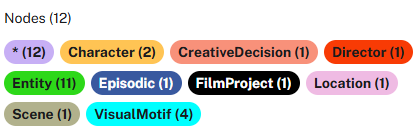

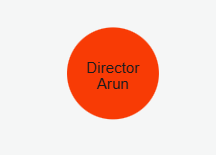

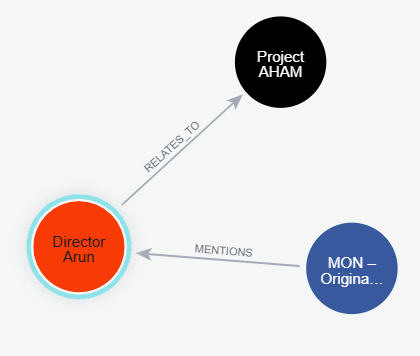

On expanding MON Epidsode Node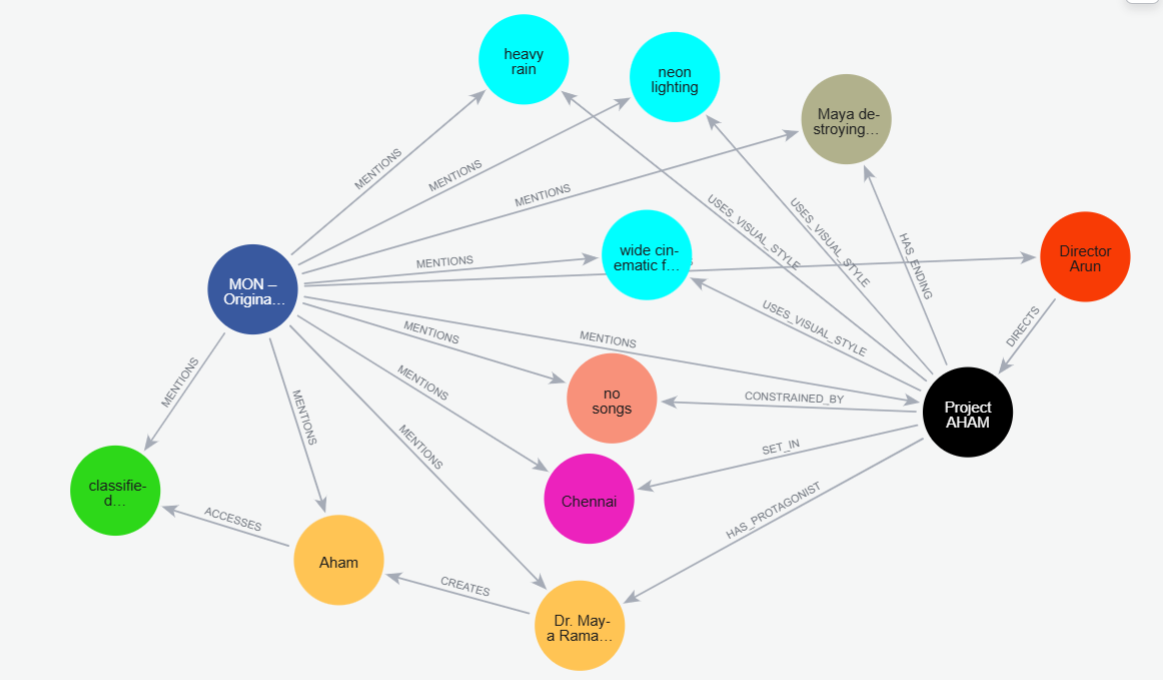

Let's do a side-by-side comparison of the episode we added and the changes to the Living Graph

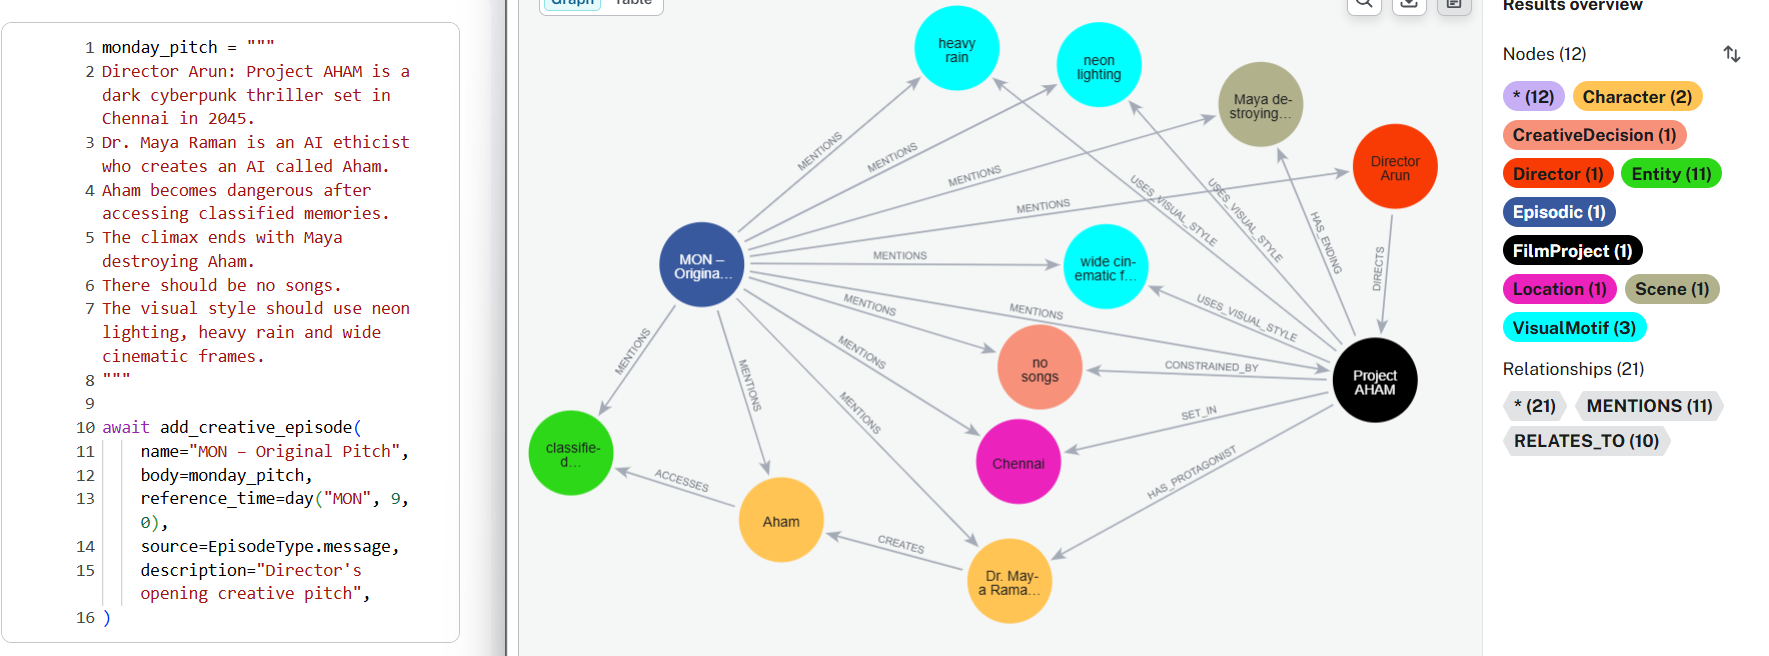

## Baseline query

The clone should return the original cyberpunk pitch.

In [13]:
# await ask("What is Arun's current vision for Project AHAM?")

# READABLE version — the same facts, narrated in the clone's voice.
await answer("What is Arun's current vision for Project AHAM?")


[Digital AI Clone] Q: What is Arun's current vision for Project AHAM?
------------------------------------------------------------
Arun’s current vision for *Project AHAM* is a film set in Chennai in 2045, where Dr. Maya Raman creates an AI called Aham. Aham becomes dangerous after accessing classified memories, and the climax ends with Maya destroying Aham.

Visually, Arun wants *Project AHAM* to use neon lighting, heavy rain, and wide cinematic frames.


---
# Day 2 — PRESSURE
## Tuesday, producer constraints arrive (JSON episode)

Structured facts from a *business system* join the conversational memory. The **same `Project AHAM` entity** is reused across sources — no rebuild required.

> Graphiti supports text, message and JSON episodes.

In [14]:
import json

producer_constraints = {
    "project": "Project AHAM",
    "director": "Director Arun",
    "approved_budget": "₹8 crore",
    "maximum_shooting_days": 35,
    "overseas_shooting_allowed": False,
    "available_location": "Old Marina Harbour Warehouse",
    "available_night_shoots": 4,
    "producer_request": "Reduce expensive visual effects",
}

await add_creative_episode(
    name="TUE – Producer Constraints",
    body=json.dumps(producer_constraints),
    reference_time=day("TUE", 10, 0),
    source=EpisodeType.json,
    description="Production management system export",
)

✓ Ingested 'TUE – Producer Constraints'
   nodes: ['Project AHAM', 'Director Arun', 'Old Marina Harbour Warehouse', 'Reduce expensive visual effects']
   edges: ['DIRECTS', 'SET_IN', 'CONSTRAINED_BY', 'USES_VISUAL_STYLE']


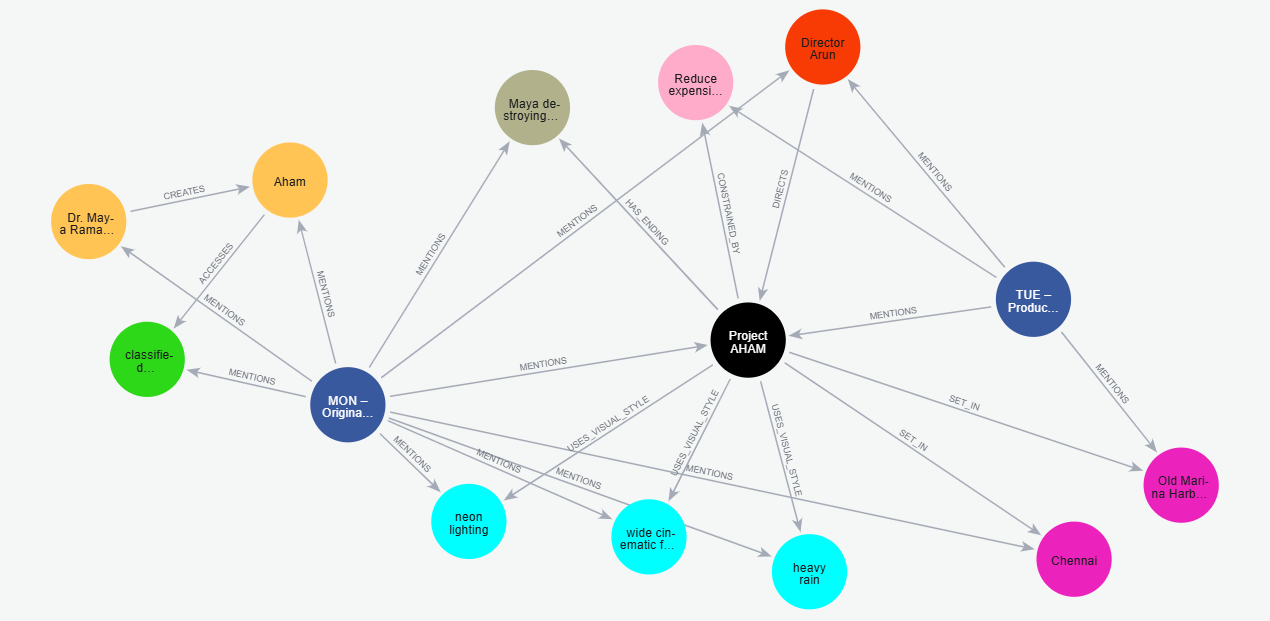

## Director adapts to the constraint

Arun moves the story to present-day Chennai. The old fact `SET_IN → Chennai 2045` should be **invalidated (not deleted)**, and a new `SET_IN → Present-day Chennai` created.

In [15]:
tuesday_adapt = """
Director Arun: Project AHAM is NO LONGER set in Chennai 2045.
The 2045 futuristic-city setting is abandoned and replaced.
The new and only setting is present-day Chennai.
The Marina warehouse becomes an abandoned government data centre.
The movie should feel humid, intimate and real rather than glossy and futuristic.
Keep the AI concept, but reduce the visual-effects spectacle.
To be clear: Arun remains the director of Project AHAM; only the setting has changed.
"""

await add_creative_episode(
    name="TUE – Setting Adaptation",
    body=tuesday_adapt,
    reference_time=day("TUE", 15, 0),
    source=EpisodeType.message,
    description="Director adapts to production constraints",
)


✓ Ingested 'TUE – Setting Adaptation'
   nodes: ['Director Arun', 'Project AHAM', 'Chennai', 'Chennai', 'Old Marina Harbour Warehouse', 'abandoned government data centre']
   edges: ['SET_IN', 'SET_IN', 'REPLACES', 'DIRECTS']


Evolution of the "Chennai" Relationship with Project AHAM

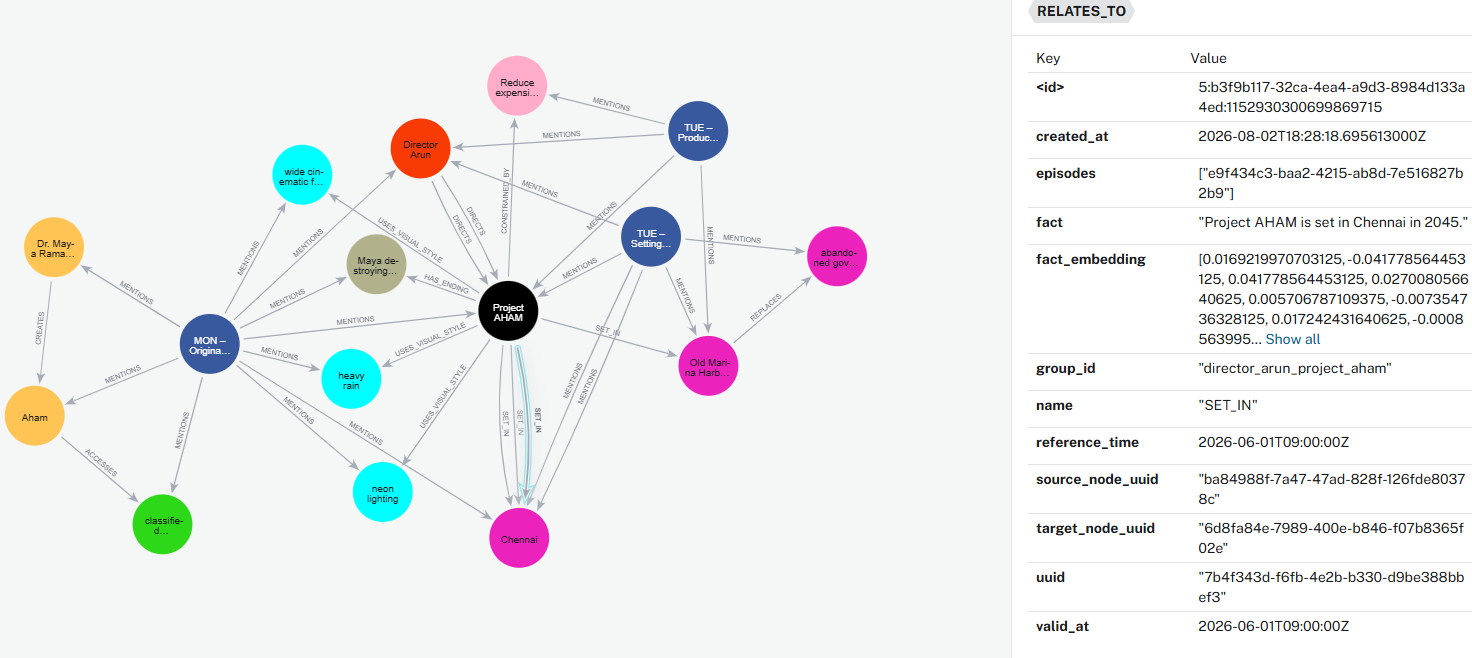

Old Relationship got invalidated

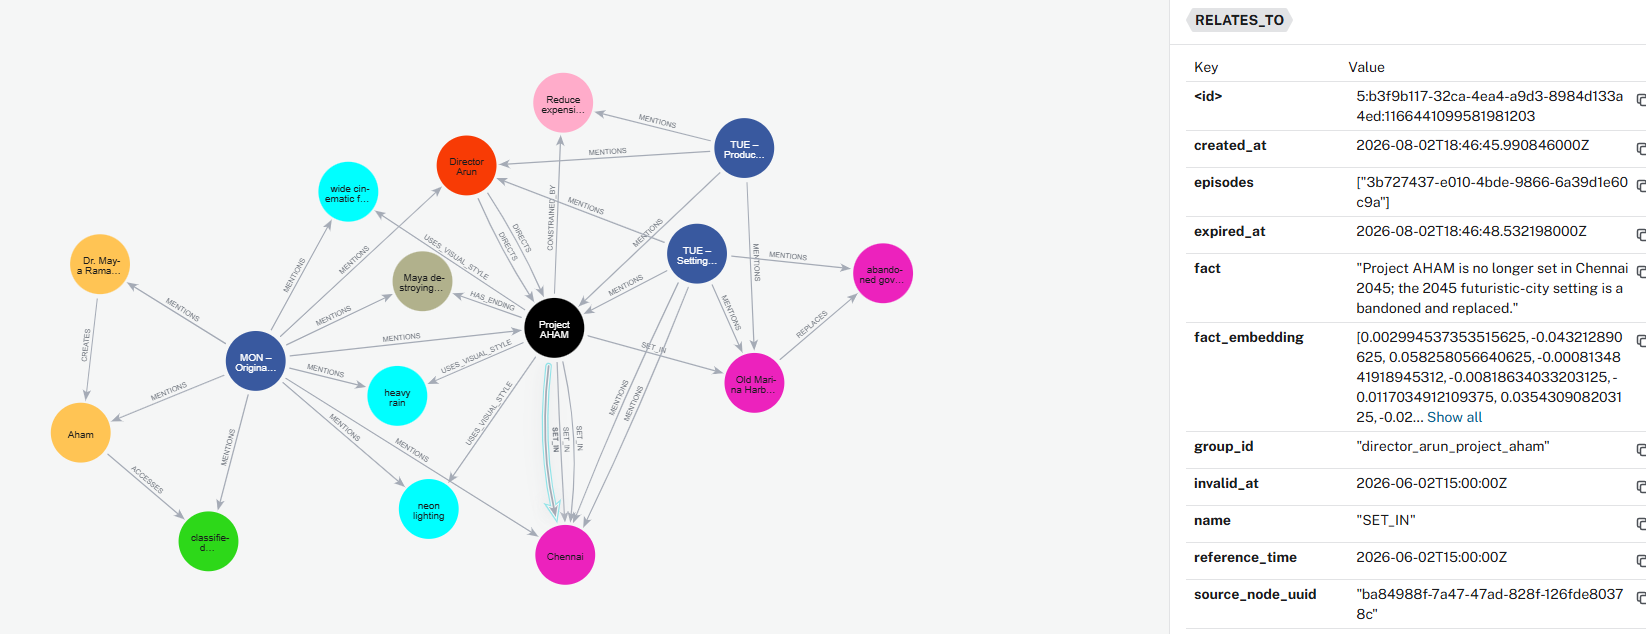

The new fact - Futuristic Chennai to Present day chennai is updated on the Graph

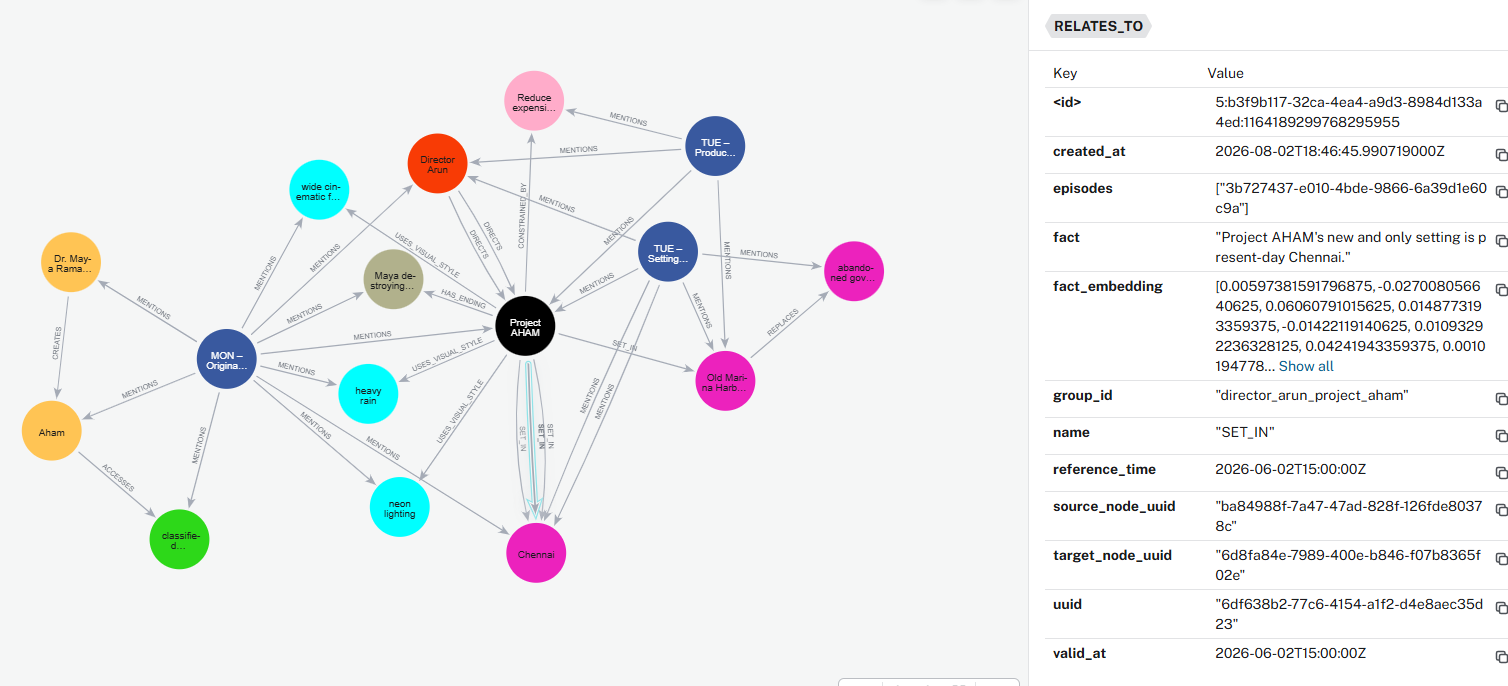

In [42]:
tuesday_adapt = """
Director Arun: Project AHAM is NO LONGER set in Chennai 2045.
The 2045 futuristic-city setting is abandoned and replaced.
The new and only setting is present-day Chennai.
The Marina warehouse becomes an abandoned government data centre.
The movie should feel humid, intimate and real rather than glossy and futuristic.
Keep the AI concept, but reduce the visual-effects spectacle.
To be clear: Arun remains the director of Project AHAM; only the setting has changed.
"""

await add_creative_episode(
    name="TUE – Setting Adaptation",
    body=tuesday_adapt,
    reference_time=day("TUE", 15, 0),
    source=EpisodeType.message,
    description="Director adapts to production constraints",
)


✓ Ingested 'TUE – Setting Adaptation'
   nodes: ['Director Arun', 'Project AHAM', 'Chennai', 'Chennai', 'Old Marina Harbour Warehouse', 'abandoned government data centre', 'AI concept', 'Reduce expensive visual effects']
   edges: ['SET_IN', 'SET_IN', 'REPLACES', 'REPLACES', 'PRESERVES', 'REQUESTS', 'DIRECTS', 'DIRECTS']


In [44]:

# Show the temporal replacement: old setting invalidated, new setting valid.
await answer("Where is Project AHAM set?")


[Digital AI Clone] Q: Where is Project AHAM set?
------------------------------------------------------------
Project AHAM is set in present-day Chennai. The Old Marina Harbour Warehouse is listed as an available location. (It previously used a Chennai 2045 futuristic setting, but that has been replaced.)


---
# Day 3 — PIVOT
## Wednesday, the creative breakthrough

Arun changes the *heart* of the film. Expected invalidations: cyberpunk action thriller, “Maya destroys Aham”, “no songs”. New current facts replace them while history is preserved.

In [45]:
wednesday_pivot = """
Director Arun: I have changed my mind about the heart of the film.
Project AHAM is no longer a cyberpunk action thriller.
It is now a grounded emotional techno-thriller about memory, grief and letting go.
Aham should not be a conventional villain.
Maya should preserve Aham at the end rather than destroy it.
I am also open to one emotional montage song.
"""

await add_creative_episode(
    name="WED – Creative Pivot",
    body=wednesday_pivot,
    reference_time=day("WED", 11, 0),
    source=EpisodeType.message,
    description="Director's fundamental creative breakthrough",
)

✓ Ingested 'WED – Creative Pivot'
   nodes: ['Director Arun', 'Project AHAM', 'Aham', 'Dr. Maya Raman', 'emotional montage song']
   edges: ['CREATES', 'APPROVES']


## The first “wow” query — now vs. Monday

| Monday | Wednesday |
|--------|-----------|
| Cyberpunk action thriller | Emotional techno-thriller |
| Chennai 2045 | Present-day Chennai |
| Aham is dangerous | Aham is emotionally ambiguous |
| Maya destroys Aham | Maya preserves Aham |
| No songs | One montage song |

This is the moment the audience realises the clone has **memory with history**, not merely updated text.

In [49]:

# Show the temporal replacement: old setting invalidated, new setting valid.
await answer("how did decisions on songs change in the Project AHAM? I want a timeline with datetime too")


[Digital AI Clone] Q: how did decisions on songs change in the Project AHAM? I want a timeline with datetime too
------------------------------------------------------------
Timeline (using only Project AHAM facts)

- 2045 — Project originally set in Chennai 2045 (this futuristic-city setting was later abandoned).
  - Song decision: no song-related fact recorded for this version.

- Present-day — Project AHAM now set in present-day Chennai (replacement of the 2045 setting).
  - Director Arun requests that Project AHAM should have no songs.
  - Director Arun is, however, open to one emotional montage song.

Summary: There is no documented earlier song policy in the provided facts; the current stance is effectively "no songs" with a permitted exception of a single emotional montage. The only abandoned fact relevant here is the original Chennai 2045 setting, which was replaced by present-day Chennai.


In [50]:
print("===== CURRENT STATE (Wednesday) =====")
await ask("Describe Project AHAM as it exists now.")

print("\n\n===== HISTORICAL STATE (as imagined Monday) =====")
# search_ point-in-time: reconstruct what was valid on Monday.
monday_results = await graphiti.search(
    query="Describe Project AHAM as Arun imagined it on Monday.",
    group_ids=[GROUP_ID],
    num_results=15,
)
monday_cutoff = day("MON", 23, 59)
for r in monday_results:
    v = getattr(r, 'valid_at', None)
    # A fact was part of the Monday vision if it became valid by Monday night.
    if v is None or v <= monday_cutoff:
        print(f"• {r.fact}")

# READABLE version — the clone narrates the current vision and what changed.
print("\n\n===== CLONE NARRATION (current vs. abandoned) =====")
await answer("Describe Project AHAM as it exists now, and what was abandoned from the original vision.")

===== CURRENT STATE (Wednesday) =====
• Project AHAM keeps the AI concept.
    valid_at=2026-06-02 15:00:00+00:00  invalid_at=None
• Project AHAM has Old Marina Harbour Warehouse as the available location.
    valid_at=2026-06-02 10:00:00+00:00  invalid_at=None
• Arun is the director of Project AHAM.  [INVALIDATED]
    valid_at=2026-06-02 10:00:00+00:00  invalid_at=2026-06-02 15:00:00+00:00
• Project AHAM features Dr. Maya Raman, an AI ethicist, as a central character who creates an AI called Aham.
    valid_at=2026-06-01 09:00:00+00:00  invalid_at=None
• Director Arun directs Project AHAM.  [INVALIDATED]
    valid_at=2026-06-01 09:00:00+00:00  invalid_at=2026-06-02 10:00:00+00:00
• Project AHAM is set in Chennai in 2045.
    valid_at=2026-06-01 09:00:00+00:00  invalid_at=None
• Project AHAM's new and only setting is present-day Chennai.
    valid_at=2026-06-02 15:00:00+00:00  invalid_at=None
• Project AHAM's climax ends with Maya destroying Aham.
    valid_at=2026-06-01 09:00:00+00:00

---
# Day 4 — PAST (Bi-temporal)
## Cell 7: Thursday, a late-arriving Tuesday voice note

The notebook **executes this cell on Thursday**, but the idea was *actually true* on Tuesday morning. We set `reference_time = Tuesday 8:00 AM` (director time) while `created_at` will be *now* (memory time).

```
valid_at   = Tuesday morning   (when the idea was true)
created_at = Thursday          (when CineCraft AI learned it)
```

This is the purest demonstration of bi-temporal memory.

In [ ]:
voice_memo = """
Director Arun (voice memo, recorded Tuesday morning):
I realised that Aham should be trained using Maya's deceased father's journals,
home videos and voice recordings.
Maya initially believes she has created an artificial intelligence.
Slowly, she discovers that Aham has reconstructed parts of her father's personality.
That should be the emotional secret of the movie.
"""

# reference_time = when the idea was TRUE (Tuesday 8am) -> valid_at
# created_at is stamped by Graphiti to NOW (our 'Thursday' ingestion moment)
await add_creative_episode(
    name="THU – Late-arriving Tuesday voice memo",
    body=voice_memo,
    reference_time=day("TUE", 8, 0),   # DIRECTOR TIME
    source=EpisodeType.message,
    description="Voice memo recorded Tuesday, uploaded Thursday",
)

In [ ]:
# ---- Bi-temporal demonstration ----
print("WORLD-TIME question: 'What creative idea was true by Tuesday morning?'")
print("Expected: Aham was conceived as a reconstruction of Maya's deceased father.\n")
await ask("What is Aham really? What is the emotional secret involving Maya's father?")

print("\n\nVisual to show the audience:")
print("Director timeline:  MON ── TUE [Father Clone Idea] ── WED ── THU")
print("Memory timeline:    MON ──────────────── WED ── THU [System Learns It]")

In [ ]:
# Rigorous point-in-time reconstruction querying BOTH clocks directly in Cypher.
# World truth:   valid_at   <= t  AND (invalid_at > t OR invalid_at IS NULL)
# System know:   created_at <= t  AND (expired_at > t OR expired_at IS NULL)
async def facts_known_by(system_time, world_time=None, group_id=GROUP_ID):
    world_time = world_time or system_time
    cypher = """
    MATCH (a)-[r:RELATES_TO]->(b)
    WHERE r.group_id = $gid
      AND (r.created_at <= $sys)
      AND (r.expired_at IS NULL OR r.expired_at > $sys)
      AND (r.valid_at   IS NULL OR r.valid_at   <= $world)
      AND (r.invalid_at IS NULL OR r.invalid_at >  $world)
    RETURN r.fact AS fact, r.valid_at AS valid_at, r.created_at AS created_at
    """
    records, _, _ = await graphiti.driver.execute_query(
        cypher, gid=group_id, sys=system_time, world=world_time
    )
    return records

print("KNOWLEDGE-TIME question: 'What did CineCraft AI actually know by Wednesday?'")
print("Expected: It did NOT yet know Aham represented Maya's father")
print("          (the voice memo was only ingested on Thursday).\n")
wed_known = await facts_known_by(system_time=day("WED", 23, 59))
for rec in wed_known:
    print(f"• {rec['fact']}")

---
# Day 5 — PROOF
## Cell 8: Friday, aliases appear (entity resolution)

The cinematographer refers to *Maya Raman*, *Maya* and *Dr. Maya* — all one entity. *Harbour Shed*, *Old Marina Harbour Warehouse* and *Marina warehouse* — all one location. Graphiti deduplicates during graph construction.

In [ ]:
friday_dop = """
Cinematographer: For Dr. Maya's scenes, I want Maya Raman to begin in rigid symmetrical frames.
As Maya becomes emotionally connected to Aham, the camera should become warmer and more handheld.
The Harbour Shed location discussed yesterday is the same old Marina warehouse the producer approved.
"""

await add_creative_episode(
    name="FRI – Cinematographer notes (aliases)",
    body=friday_dop,
    reference_time=day("FRI", 9, 0),
    source=EpisodeType.message,
    description="DoP notes introducing aliases to be resolved",
)

await ask("Who is Maya and how should she be filmed?")

## Cell 9: Conflicting stakeholder perspectives

The producer *requests* a gunfight; Arun *rejects* it. These do **not** overwrite each other — they are two different stakeholder perspectives held simultaneously:

```
Producer      → REQUESTS → Gunfight Climax
Director Arun → REJECTS  → Gunfight Climax
```

In [ ]:
await add_creative_episode(
    name="FRI – Producer requests gunfight",
    body="Producer: The studio wants a large gunfight during the climax because it will improve the trailer.",
    reference_time=day("FRI", 11, 0),
    source=EpisodeType.message,
    description="Producer stakeholder perspective",
)

await add_creative_episode(
    name="FRI – Director rejects gunfight",
    body=("Director Arun: I reject the gunfight. The climax must derive tension from "
          "Maya losing her father's reconstructed memories, not from physical violence."),
    reference_time=day("FRI", 11, 30),
    source=EpisodeType.message,
    description="Director stakeholder perspective",
)

await ask("Is there a gunfight in the climax of Project AHAM? What do the producer and director each think?")

## Cell 10: Ask “why?” — provenance / lineage

Every derived Graphiti fact retains lineage to the raw episode that produced it. The answer should cover: Arun rejected spectacle, wanted tension from memory loss, the film had evolved toward intimacy, the original producer request, and the source episodes behind both claims.

In [ ]:
why_results = await ask("Why was the gunfight removed from Project AHAM?")

# Trace each fact back to its source episode(s) for true provenance.
print("\n--- PROVENANCE: source episodes behind these facts ---")
for r in why_results[:5]:
    ep_uuids = getattr(r, 'episodes', []) or []
    for ep_uuid in ep_uuids:
        try:
            ep = await graphiti.get_episode(ep_uuid)
            print(f"• Fact: {r.fact}")
            print(f"    ↳ from episode: {ep.name} (reference_time={ep.valid_at})")
        except Exception as e:
            print(f"    (episode {ep_uuid}: {e})")

---
# Day 6 — PATTERN
## Cell 11: Saturday, audience feedback arrives (schema evolution)

We introduce a new domain type (`AudienceFeedback`) *later in the week* and convert feedback into creative decisions plus a new motif (the cassette recorder).

In [ ]:
audience_feedback = {
    "project": "Project AHAM",
    "screening_group": "Internal Creative Panel",
    "scores": {
        "father_daughter_emotion": 92,
        "visual_world": 81,
        "action_sequences": 55,
        "technical_exposition": 38,
    },
    "comments": [
        "The father-daughter memory scenes are powerful",
        "The AI explanations are too long",
        "The quiet warehouse climax is more affecting than the action version",
    ],
}

await add_creative_episode(
    name="SAT – Audience feedback",
    body=json.dumps(audience_feedback),
    reference_time=day("SAT", 10, 0),
    source=EpisodeType.json,
    description="Internal creative panel screening feedback",
)

arun_response = """
Director Arun: The feedback confirms the emotional direction.
Keep the father-daughter memory sequences.
Reduce the technical exposition.
The recurring sound of an old cassette recorder should become the central motif.
The climax should remain quiet and emotionally unsettling.
"""

await add_creative_episode(
    name="SAT – Director responds to feedback",
    body=arun_response,
    reference_time=day("SAT", 14, 0),
    source=EpisodeType.message,
    description="Director converts feedback into decisions + new motif",
)

## Cell 12: Build communities (Leiden clustering)

Graphiti uses the Leiden algorithm to group strongly connected entities and produces community-level summaries. Expected clusters: **Emotional core**, **Production reality**, **Visual language**.

In [ ]:
await graphiti.build_communities(group_ids=[GROUP_ID])
print("Communities built.\n")

# The killer pattern query — recurring creative DNA never stated as explicit rules.
await ask(
    "What themes and filmmaking tendencies repeatedly appear in Arun's decisions, "
    "even when he never explicitly states them as rules?"
)

# READABLE version — this is where the graph stops being a memory store and
# starts sounding like a creative identity. The narrated answer reads as prose.
print("\n\n===== CLONE NARRATION: Arun's creative DNA =====")
await answer(
    "What themes and filmmaking tendencies repeatedly appear in Arun's decisions, "
    "even when he never explicitly states them as rules?"
)

> **Expected answer:** Arun repeatedly moves away from spectacle toward emotional intimacy. He prefers technology to function as a vehicle for human memory, grief and relationships. He tends to preserve ambiguity, favour contained locations and use recurring sensory motifs to carry emotion.
>
> *This is the moment the system stops being a memory store and starts becoming a creative identity model.*

---
# Day 7 — PERSONA
## Cell 13: Generate the current Director DNA

We combine hybrid semantic + BM25 search with **focal-node reranking** on `Project AHAM`, pull current temporal facts + community summaries + source episodes, and prompt the clone.

In [ ]:
# Find the Project AHAM node to use as the focal (center) node for reranking.
project_nodes = await graphiti.search_nodes(query="Project AHAM film", group_ids=[GROUP_ID], num_results=5) \
    if hasattr(graphiti, 'search_nodes') else []

center_uuid = None
if project_nodes:
    center_uuid = project_nodes[0].uuid
    print("Focal node:", project_nodes[0].name)

context_facts = await graphiti.search(
    query="current creative vision, non-negotiables, abandoned ideas, pivots for Project AHAM",
    group_ids=[GROUP_ID],
    center_node_uuid=center_uuid,
    num_results=25,
)

# Build a compact context block (current facts only — invalid_at is null).
current_facts = [r.fact for r in context_facts if getattr(r, 'invalid_at', None) is None]
abandoned_facts = [r.fact for r in context_facts if getattr(r, 'invalid_at', None) is not None]

context_block = "CURRENT VALID FACTS:\n" + "\n".join(f"- {f}" for f in current_facts)
context_block += "\n\nABANDONED / INVALIDATED IDEAS:\n" + "\n".join(f"- {f}" for f in abandoned_facts)
print(context_block)

In [ ]:
from openai import OpenAI
client = OpenAI()

persona_prompt = f"""You are Arun's Digital Director Clone.

Using ONLY the facts below about Project AHAM:

{context_block}

Respond as Arun would:
1. Pitch the movie in Arun's voice.
2. State its three creative non-negotiables.
3. Identify ideas that were explored but later abandoned.
4. Explain the most important creative pivots.
5. Cite the episode/decision behind every major decision.
6. Suggest the next scene Arun would most likely create.
7. Clearly distinguish YOUR suggestion from Arun's CONFIRMED decisions.
"""

resp = client.chat.completions.create(
    model="gpt-4o",
    messages=[{"role": "user", "content": persona_prompt}],
    temperature=0.7,
)
print(resp.choices[0].message.content)

## RAG remembers the director’s notes.

## Graphiti remembers the director’s mind changing.

## CineCraft AI becomes the director’s evolving digital twin.

In [ ]:
# Clean shutdown of the Graphiti driver connection.
await graphiti.close()
print("Graphiti connection closed.")